# Algeria Export Opportunity Analysis — Clustering Phase

**Objective:** Apply unsupervised learning to classify Algerian export opportunities, benchmark the country's macroeconomic profile against peers, and identify broad trade sector archetypes.

This notebook is organized into **three clustering tasks**:

| # | Task | Algorithm | Data Source |
|---|------|-----------|-------------|
| 1 | Product-Level Opportunity Classification | K-Means | `algeria_features.csv` + `product_export.csv` |
| 2 | Country Macroeconomic Benchmarking | Agglomerative Clustering | `04_master_country_year.csv` |
| 3 | WTO Sector Archetype Discovery | DBSCAN | `04_master_sector_year.csv` |

All input data was produced by the preprocessing pipeline. No raw downloads or synthesis are performed here.

## 0. Environment Setup & Configuration

In [33]:
# ============================================================
# 0.1  Imports
# ============================================================
import warnings, os, pathlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# SciPy for dendrograms
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Plot defaults
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})

print("All imports successful.")

All imports successful.


In [34]:
# ============================================================
# 0.2  Paths  —  Change DATA_DIR to match your data location
# ============================================================
DATA_DIR = "../../data/processed/"   # <-- relative path from this notebook to data/processed
OUTPUT_DIR = "./output/"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"DATA_DIR  : {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

DATA_DIR  : ../../data/processed/
OUTPUT_DIR: ./output/


---
# Task 1: Product-Level Opportunity Classification (K-Means)

## Economic Context

Algeria currently has **0 % market share in 3,905 out of ~5,200 globally traded HS6 product categories**. Only 27 products exceed 1 % share, and a mere 3 surpass 10 % — almost all hydrocarbons.

**Goal:** Cluster all products into actionable priority tiers (e.g., *High Opportunity*, *Medium / Niche*, *Low Priority*) so that policy-makers can focus resources on the most promising diversification targets.

### Why we apply specific transformations

| Transformation | Reason |
|---|---|
| `log1p(Global_Demand)` | Raw demand spans 6+ orders of magnitude (median \$9.89 k vs max \$42.7 B). Without log-scaling, K-Means distances are dominated by a handful of mega-products and the vast majority of goods collapse to a single point near the origin. |
| `log1p(Untapped_Potential)` | Same skewness problem — untapped potential inherits the distribution of global demand. |
| `clip(Export_Growth_Rate, -200, 200)` | Growth rates computed via `pct_change()` produce extreme outliers (e.g., +1 400 %) when a product goes from near-zero to any positive value. Clipping preserves the signal while preventing a single volatile product from distorting cluster centroids. |
| `StandardScaler` | K-Means uses Euclidean distance. Features on different scales (share in [0, 100], log-demand in [0, 25]) would bias the algorithm toward the numerically largest feature. Standardising to zero-mean / unit-variance ensures each feature contributes equally. |

### 1.1 Load & Merge Data

In [35]:
# ── 1.1  Load pre-aggregated files ──────────────────────────────────────────
algeria = pd.read_csv(DATA_DIR + "algeria_features.csv")
product_export = pd.read_csv(DATA_DIR + "product_export.csv")

print("algeria_features.csv :", algeria.shape)
print("product_export.csv   :", product_export.shape)
algeria.head()

algeria_features.csv : (67585, 6)
product_export.csv   : (7217808, 7)


,Year,Product,Algeria_Exports,Algeria_Market_Share,Global_Demand,Untapped_Potential
0,2012,610469,0.000,0.0000,822330.024,822330.024
1,2012,630900,5.017,0.0001,3886645.949,3886640.932
2,2012,91099,9.167,0.0016,583110.273,583101.106
3,2012,392630,24.720,0.0008,3252724.741,3252700.021
4,2012,710310,0.000,0.0000,680218.859,680218.859


In [36]:
# ── 1.1b  Filter product_export to Algeria only & merge ────────────────────
dza_exports = product_export[product_export["Exporter_ISO3"] == "DZA"][
    ["Year", "Product", "Market_Share", "Export_Growth_Rate"]
].copy()

print(f"Algeria rows in product_export: {len(dza_exports):,}")

# Merge onto algeria_features to combine demand-side + supply-side features
opp = algeria.merge(dza_exports, on=["Year", "Product"], how="left")

# Products Algeria does not export at all will have NaN for Market_Share / Growth
opp["Market_Share"] = opp["Market_Share"].fillna(0.0)
opp["Export_Growth_Rate"] = opp["Export_Growth_Rate"].fillna(0.0)

print(f"Merged opportunity table : {opp.shape}")
opp.head()

Algeria rows in product_export: 23,382
Merged opportunity table : (67585, 8)


,Year,Product,Algeria_Exports,Algeria_Market_Share,Global_Demand,Untapped_Potential,Market_Share,Export_Growth_Rate
0,2012,610469,0.000,0.0000,822330.024,822330.024,0.0000,0.0
1,2012,630900,5.017,0.0001,3886645.949,3886640.932,0.0001,0.0
2,2012,91099,9.167,0.0016,583110.273,583101.106,0.0016,0.0
3,2012,392630,24.720,0.0008,3252724.741,3252700.021,0.0008,0.0
4,2012,710310,0.000,0.0000,680218.859,680218.859,0.0000,0.0


### 1.2 Preprocessing

In [37]:
# ── 1.2  Feature engineering & scaling ──────────────────────────────────────
CLUSTER_FEATURES = ["Global_Demand", "Untapped_Potential", "Market_Share", "Export_Growth_Rate"]

# Use the latest year only to avoid temporal autocorrelation inflating distances
latest_year = opp["Year"].max()
opp_latest = opp[opp["Year"] == latest_year].copy()
print(f"Using latest year: {latest_year}  |  rows: {len(opp_latest):,}")

# Log-transform skewed monetary columns
opp_latest["Global_Demand"] = np.log1p(opp_latest["Global_Demand"])
opp_latest["Untapped_Potential"] = np.log1p(opp_latest["Untapped_Potential"])

# Clip extreme growth rates
opp_latest["Export_Growth_Rate"] = opp_latest["Export_Growth_Rate"].clip(-200, 200)

# Drop rows with any remaining NaNs in clustering features
opp_clean = opp_latest.dropna(subset=CLUSTER_FEATURES).reset_index(drop=True)
print(f"After dropna: {len(opp_clean):,} products")

# Scale
scaler_opp = StandardScaler()
X_opp = scaler_opp.fit_transform(opp_clean[CLUSTER_FEATURES])
print(f"Scaled feature matrix shape: {X_opp.shape}")

# Quick sanity check
pd.DataFrame(X_opp, columns=CLUSTER_FEATURES).describe().round(2)

Using latest year: 2024  |  rows: 5,198
After dropna: 5,198 products
Scaled feature matrix shape: (5198, 4)


,Global_Demand,Untapped_Potential,Market_Share,Export_Growth_Rate
count,5198.00,5198.00,5198.00,5198.00
mean,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00
min,-6.35,-6.35,-0.06,-1.53
25%,-0.54,-0.54,-0.06,-0.17
50%,0.06,0.06,-0.06,-0.17
75%,0.64,0.64,-0.06,-0.17
max,3.63,3.62,45.59,2.54


### 1.3 Determine Optimal *k* — Elbow Method & Silhouette Analysis

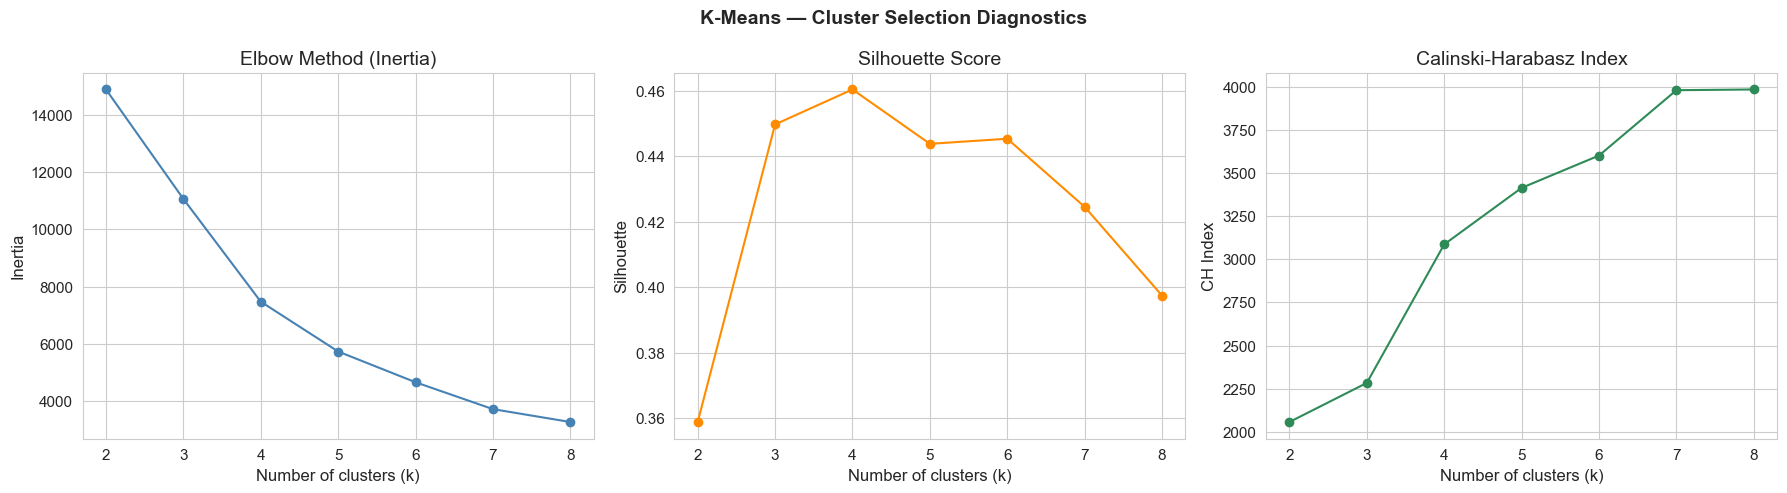

,k,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,"14,896",0.3588,1.0272,"2,057"
1,3,"11,065",0.4498,0.7697,"2,283"
2,4,"7,471",0.4605,0.6809,"3,087"
3,5,"5,727",0.4439,0.6806,"3,415"
4,6,"4,652",0.4454,0.6181,"3,602"
5,7,"3,712",0.4246,0.6488,"3,982"
6,8,"3,261",0.3975,0.7023,"3,986"


In [38]:
# ── 1.3  Elbow + Silhouette search ─────────────────────────────────────────
K_RANGE = range(2, 9)

inertias = []
sil_scores = []
db_scores = []
ch_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_opp)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_opp, labels))
    db_scores.append(davies_bouldin_score(X_opp, labels))
    ch_scores.append(calinski_harabasz_score(X_opp, labels))

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(K_RANGE), inertias, "o-", color="steelblue")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_RANGE), sil_scores, "o-", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette")

axes[2].plot(list(K_RANGE), ch_scores, "o-", color="seagreen")
axes[2].set_title("Calinski-Harabasz Index")
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("CH Index")

plt.suptitle("K-Means — Cluster Selection Diagnostics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary table
eval_df = pd.DataFrame({
    "k": list(K_RANGE),
    "Inertia": [f"{v:,.0f}" for v in inertias],
    "Silhouette": [f"{v:.4f}" for v in sil_scores],
    "Davies-Bouldin": [f"{v:.4f}" for v in db_scores],
    "Calinski-Harabasz": [f"{v:,.0f}" for v in ch_scores],
})
eval_df

### 1.4 Fit Final K-Means Model & Label Clusters

We select the best *k* based on the **highest Silhouette score** from the evaluation above. After fitting, we inspect each cluster's centroid (in original feature space) to assign economically meaningful labels.

In [39]:
# ── 1.4  Select optimal k automatically (best silhouette) ──────────────────
optimal_k = list(K_RANGE)[int(np.argmax(sil_scores))]
print(f"Optimal k (max silhouette): {optimal_k}")

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
opp_clean["cluster"] = km_final.fit_predict(X_opp)

# ── Centroid analysis in ORIGINAL (unscaled, but log-transformed) space ────
centroids_scaled = km_final.cluster_centers_
centroids_original = scaler_opp.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=CLUSTER_FEATURES)
centroid_df.index.name = "cluster"
print("\nCluster centroids (log-space for demand/potential):\n")
centroid_df

Optimal k (max silhouette): 4

Cluster centroids (log-space for demand/potential):



,Global_Demand,Untapped_Potential,Market_Share,Export_Growth_Rate
cluster,,,,
0,14.523185,14.523033,0.015156,-17.760700
1,14.818436,14.718643,9.310808,-16.766283
2,11.303895,11.303808,0.008610,-3.259422
3,14.536513,14.536324,0.018898,185.644751


In [40]:
# ── 1.4b  Assign human-readable labels based on centroid characteristics ───
#
# Labelling strategy:
#   - Rank clusters by Untapped_Potential centroid (descending).
#   - Highest  → "High Opportunity"
#   - Lowest   → "Low Priority"
#   - Middle ones → "Niche / Medium" variants
#
# This is a heuristic; domain experts should validate.

centroid_df["_rank"] = centroid_df["Untapped_Potential"].rank(ascending=False).astype(int)

label_pool = {
    1: "High Opportunity",
    2: "Medium Opportunity",
    3: "Niche / Emerging",
    4: "Low Priority",
    5: "Marginal",
    6: "Negligible",
    7: "Irrelevant",
    8: "Noise",
}

cluster_label_map = {}
for cluster_id, row in centroid_df.iterrows():
    rank = row["_rank"]
    cluster_label_map[cluster_id] = label_pool.get(rank, f"Tier-{rank}")

centroid_df["Label"] = centroid_df.index.map(cluster_label_map)
centroid_df.drop(columns=["_rank"], inplace=True)

opp_clean["Opportunity_Label"] = opp_clean["cluster"].map(cluster_label_map)

print("Cluster label mapping:")
for cid, lbl in sorted(cluster_label_map.items()):
    n = (opp_clean["cluster"] == cid).sum()
    print(f"  Cluster {cid}  →  {lbl:25s}  ({n:,} products)")

centroid_df

Cluster label mapping:
  Cluster 0  →  Niche / Emerging           (2,688 products)
  Cluster 1  →  High Opportunity           (12 products)
  Cluster 2  →  Low Priority               (1,852 products)
  Cluster 3  →  Medium Opportunity         (646 products)


,Global_Demand,Untapped_Potential,Market_Share,Export_Growth_Rate,Label
cluster,,,,,
0,14.523185,14.523033,0.015156,-17.760700,Niche / Emerging
1,14.818436,14.718643,9.310808,-16.766283,High Opportunity
2,11.303895,11.303808,0.008610,-3.259422,Low Priority
3,14.536513,14.536324,0.018898,185.644751,Medium Opportunity


### 1.5 Visualization — Opportunity Landscape

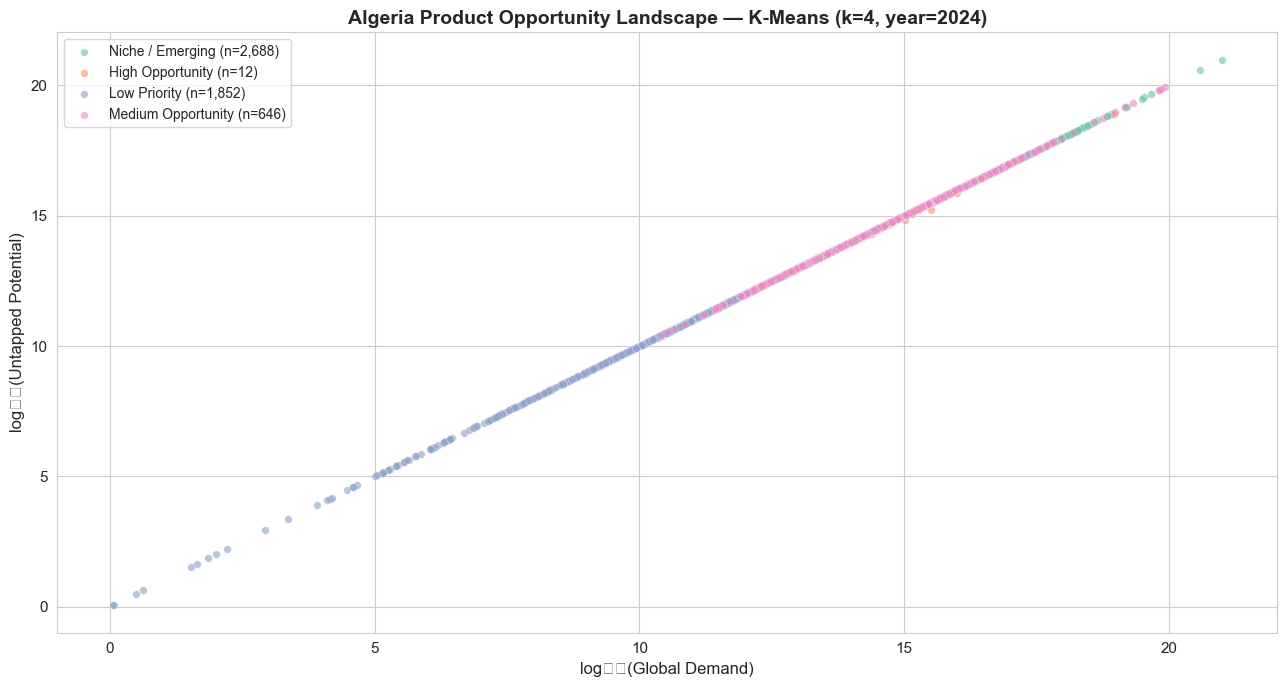

In [41]:
# ── 1.5a  Scatter: Global Demand vs Untapped Potential (log-space) ─────────
palette = sns.color_palette("Set2", n_colors=optimal_k)

fig, ax = plt.subplots(figsize=(13, 7))
for cid in sorted(opp_clean["cluster"].unique()):
    mask = opp_clean["cluster"] == cid
    lbl = cluster_label_map[cid]
    ax.scatter(
        opp_clean.loc[mask, "Global_Demand"],
        opp_clean.loc[mask, "Untapped_Potential"],
        label=f"{lbl} (n={mask.sum():,})",
        alpha=0.6,
        s=30,
        color=palette[cid],
        edgecolors="w",
        linewidth=0.3,
    )

ax.set_xlabel("log₁₊(Global Demand)")
ax.set_ylabel("log₁₊(Untapped Potential)")
ax.set_title(
    f"Algeria Product Opportunity Landscape — K-Means (k={optimal_k}, year={latest_year})",
    fontweight="bold",
)
ax.legend(loc="upper left", frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

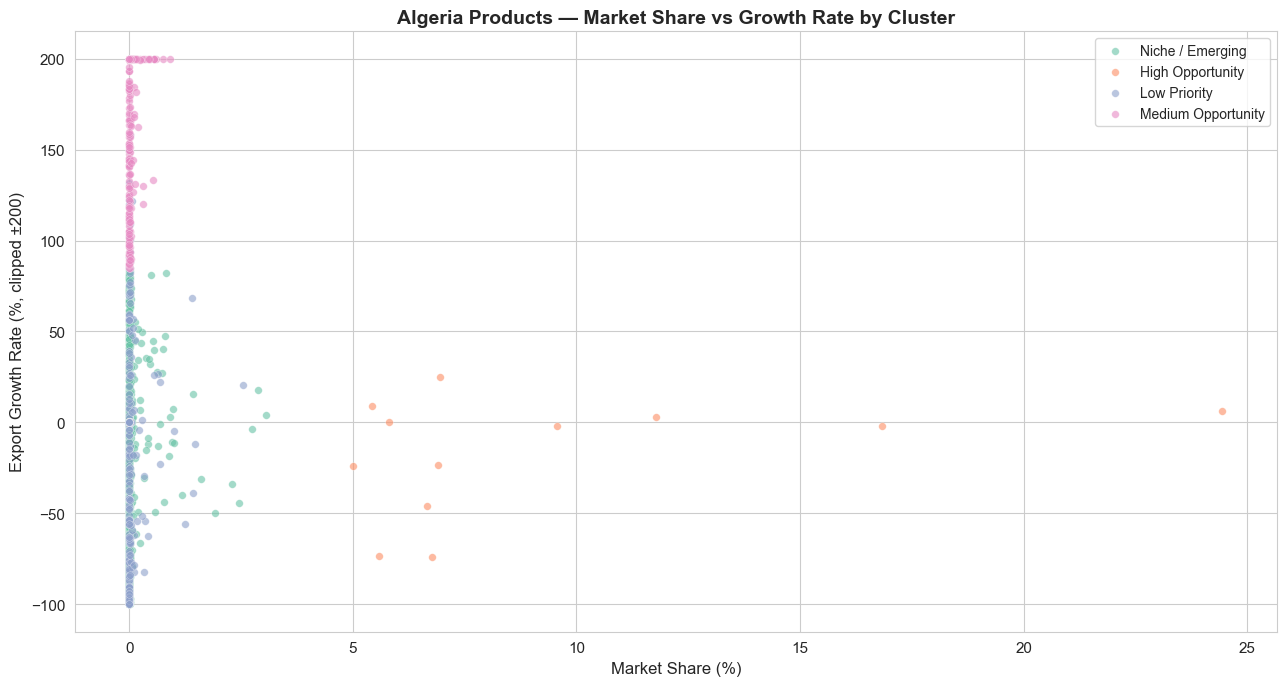

In [42]:
# ── 1.5b  Scatter: Market Share vs Export Growth Rate ──────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
for cid in sorted(opp_clean["cluster"].unique()):
    mask = opp_clean["cluster"] == cid
    lbl = cluster_label_map[cid]
    ax.scatter(
        opp_clean.loc[mask, "Market_Share"],
        opp_clean.loc[mask, "Export_Growth_Rate"],
        label=f"{lbl}",
        alpha=0.6,
        s=30,
        color=palette[cid],
        edgecolors="w",
        linewidth=0.3,
    )

ax.set_xlabel("Market Share (%)")
ax.set_ylabel("Export Growth Rate (%, clipped ±200)")
ax.set_title(
    "Algeria Products — Market Share vs Growth Rate by Cluster",
    fontweight="bold",
)
ax.legend(loc="upper right", frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

In [43]:
# ── 1.5c  Cluster profile summary ──────────────────────────────────────────
# Show median statistics per cluster in the ORIGINAL (pre-log, pre-clip) space
# so the economic meaning is clear.

opp_profile = opp_latest.copy()
opp_profile["cluster"] = opp_clean["cluster"].values[:len(opp_profile)] if len(opp_profile) == len(opp_clean) else np.nan

# Rebuild an unmodified copy for profiling
opp_profile_raw = opp[opp["Year"] == latest_year].copy()
opp_profile_raw = opp_profile_raw.dropna(subset=["Global_Demand", "Untapped_Potential"]).reset_index(drop=True)
if len(opp_profile_raw) == len(opp_clean):
    opp_profile_raw["cluster"] = opp_clean["cluster"].values
    opp_profile_raw["Opportunity_Label"] = opp_clean["Opportunity_Label"].values

    # Clip extreme growth rates to match the ±200% used in the scaled features
    opp_profile_raw["Export_Growth_Rate"] = opp_profile_raw["Export_Growth_Rate"].clip(-200, 200)

    profile = (
        opp_profile_raw
        .groupby("Opportunity_Label")[
            ["Global_Demand", "Untapped_Potential", "Market_Share", "Export_Growth_Rate", "Algeria_Exports"]
        ]
        .agg(["median", "mean", "count"])
    )
    profile.columns = ["_".join(c) for c in profile.columns]
    print("Cluster profiles (original scale):\n")
    display(profile)
else:
    print("Row count mismatch — skipping profile summary (non-critical).")

Cluster profiles (original scale):



,Global_Demand_median,Global_Demand_mean,Global_Demand_count,Untapped_Potential_median,Untapped_Potential_mean,Untapped_Potential_count,Market_Share_median,Market_Share_mean,Market_Share_count,Export_Growth_Rate_median,Export_Growth_Rate_mean,Export_Growth_Rate_count,Algeria_Exports_median,Algeria_Exports_mean,Algeria_Exports_count
Opportunity_Label,,,,,,,,,,,,,,,
High Opportunity,3.542831e+06,1.890418e+07,12,3.139064e+06,1.749778e+07,12,6.8377,9.310808,12,-1.90715,-16.766283,12,366203.1935,1.406399e+06,12
Low Priority,1.283464e+05,1.529688e+05,1852,1.283464e+05,1.529566e+05,1852,0.0000,0.008589,1852,0.00000,-3.284445,1852,0.0000,1.221115e+01,1852
Medium Opportunity,1.994306e+06,9.128763e+06,646,1.994296e+06,9.128112e+06,646,0.0007,0.018898,646,200.00000,185.644751,646,17.5480,6.513920e+02,646
Niche / Emerging,1.591495e+06,6.130237e+06,2688,1.591495e+06,6.118764e+06,2688,0.0000,0.015185,2688,0.00000,-17.775828,2688,0.0000,1.147259e+04,2688


### 1.6 Save Opportunity Clusters

In [44]:
# ── 1.6  Persist opportunity clusters ──────────────────────────────────────
opp_out = opp_clean[["Year", "Product", "Global_Demand", "Untapped_Potential",
                      "Algeria_Exports", "Algeria_Market_Share",
                      "Market_Share", "Export_Growth_Rate",
                      "cluster", "Opportunity_Label"]].copy()

opp_out.to_csv(OUTPUT_DIR + "opportunity_clusters.csv", index=False)
print(f"Saved {len(opp_out):,} rows → {OUTPUT_DIR}opportunity_clusters.csv")
opp_out.head()

Saved 5,198 rows → ./output/opportunity_clusters.csv


,Year,Product,Global_Demand,Untapped_Potential,Algeria_Exports,Algeria_Market_Share,Market_Share,Export_Growth_Rate,cluster,Opportunity_Label
0,2024,80810,15.899297,15.899297,1.588,0.0000,0.0000,147.3520,3,Medium Opportunity
1,2024,330499,17.802197,17.802194,199.842,0.0004,0.0004,149.4439,3,Medium Opportunity
2,2024,732510,14.611033,14.611033,0.000,0.0000,0.0000,0.0000,0,Niche / Emerging
3,2024,848330,15.913011,15.913011,1.006,0.0000,0.0000,-95.8034,0,Niche / Emerging
4,2024,853610,15.002454,15.002451,11.862,0.0004,0.0004,23.4468,0,Niche / Emerging


---
# Task 2: Country Macroeconomic Benchmarking (Agglomerative Clustering)

## Economic Context

Algeria needs to understand where it stands relative to other economies. Agglomerative (hierarchical) clustering is ideal here because:

1. **Dendrogram interpretability** — policy-makers can visually see which countries Algeria is closest to and at what level of dissimilarity they diverge.
2. **Ward linkage** minimises within-cluster variance, producing compact, balanced groups — appropriate for macroeconomic profiles where extreme outliers (e.g., China's GDP) are already handled by `StandardScaler`.
3. **No need to pre-specify k** — the dendrogram naturally suggests a cut-off.

### Features used (pre-scaled in preprocessing pipeline)

| Feature | Economic meaning |
|---------|-----------------|
| `NY.GDP.MKTP.CD_std` | GDP (current US$) — absolute economic size |
| `NY.GDP.MKTP.KD.ZG_std` | GDP growth (%) — dynamism |
| `NY.GDP.PCAP.CD_std` | GDP per capita — development level |
| `SP.POP.TOTL_std` | Population — market size |
| `TG.VAL.TOTL.GD.ZS_std` | Trade (% of GDP) — openness |
| `NE.IMP.GNFS.ZS_std` | Imports (% of GDP) — import dependency |

### 2.1 Load Data

In [45]:
# ── 2.1  Load master country-year panel ────────────────────────────────────
country_year = pd.read_csv(DATA_DIR + "04_master_country_year.csv")
print("Shape:", country_year.shape)
print("Columns:", country_year.columns.tolist())
country_year.head()

Shape: (5375, 56)
Columns: ['country', 'country_code', 'year', 'NE.IMP.GNFS.ZS', 'NY.GDP.MKTP.CD', 'NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD', 'SP.POP.TOTL', 'TG.VAL.TOTL.GD.ZS', 'gdp_growth_lag1', 'trade_volume_proxy', 'import_volume_proxy', 'gdp_per_capita_computed', 'NE.IMP.GNFS.ZS_std', 'NY.GDP.MKTP.CD_std', 'NY.GDP.MKTP.KD.ZG_std', 'NY.GDP.PCAP.CD_std', 'SP.POP.TOTL_std', 'TG.VAL.TOTL.GD.ZS_std', 'gdp_growth_lag1_std', 'trade_volume_proxy_std', 'import_volume_proxy_std', 'gdp_per_capita_computed_std', 'NE.IMP.GNFS.ZS_minmax', 'NY.GDP.MKTP.CD_minmax', 'NY.GDP.MKTP.KD.ZG_minmax', 'NY.GDP.PCAP.CD_minmax', 'SP.POP.TOTL_minmax', 'TG.VAL.TOTL.GD.ZS_minmax', 'gdp_growth_lag1_minmax', 'trade_volume_proxy_minmax', 'import_volume_proxy_minmax', 'gdp_per_capita_computed_minmax', 'NE.IMP.GNFS.ZS_robust', 'NY.GDP.MKTP.CD_robust', 'NY.GDP.MKTP.KD.ZG_robust', 'NY.GDP.PCAP.CD_robust', 'SP.POP.TOTL_robust', 'TG.VAL.TOTL.GD.ZS_robust', 'gdp_growth_lag1_robust', 'trade_volume_proxy_robust', 'import_volum

,country,country_code,year,NE.IMP.GNFS.ZS,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SP.POP.TOTL,TG.VAL.TOTL.GD.ZS,gdp_growth_lag1,...,shannon_entropy_norm,hhi_std,shannon_entropy_std,shannon_entropy_norm_std,hhi_minmax,shannon_entropy_minmax,shannon_entropy_norm_minmax,hhi_robust,shannon_entropy_robust,shannon_entropy_norm_robust
0,Aruba,ABW,2000.0,70.686869,1.873453e+09,7.622921,20681.023027,90588.0,272.544938,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,2001.0,69.394325,1.896457e+09,4.182002,20740.132583,91439.0,252.839903,7.622921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,2002.0,68.666458,1.961844e+09,-0.944953,21307.248251,92074.0,178.658484,4.182002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,2003.0,70.063078,2.044112e+09,1.110505,21949.485996,93128.0,217.649551,-0.944953,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,2004.0,67.765371,2.254831e+09,7.293728,23700.631990,95138.0,311.508971,1.110505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Prepare Feature Matrix

In [46]:
# ── 2.2  Select pre-scaled standard features ───────────────────────────────
COUNTRY_FEATURES = [
    "NY.GDP.MKTP.CD_std",
    "NY.GDP.MKTP.KD.ZG_std",
    "NY.GDP.PCAP.CD_std",
    "SP.POP.TOTL_std",
    "TG.VAL.TOTL.GD.ZS_std",
    "NE.IMP.GNFS.ZS_std",
]

# Verify all expected columns exist
missing = [c for c in COUNTRY_FEATURES if c not in country_year.columns]
if missing:
    print(f"WARNING — missing columns: {missing}")
else:
    print("All 6 scaled features present.")

# Drop rows with NaN in any clustering feature
cy = country_year.dropna(subset=COUNTRY_FEATURES).reset_index(drop=True)
X_country = cy[COUNTRY_FEATURES].values

print(f"Rows for clustering: {len(cy)}")
print(f"Unique countries: {cy['Country Name'].nunique() if 'Country Name' in cy.columns else 'N/A'}")
cy[["Country Name", "Year"] + COUNTRY_FEATURES].head(10) if "Country Name" in cy.columns else cy.head(10)

All 6 scaled features present.
Rows for clustering: 5375
Unique countries: N/A


,country,country_code,year,NE.IMP.GNFS.ZS,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SP.POP.TOTL,TG.VAL.TOTL.GD.ZS,gdp_growth_lag1,...,shannon_entropy_norm,hhi_std,shannon_entropy_std,shannon_entropy_norm_std,hhi_minmax,shannon_entropy_minmax,shannon_entropy_norm_minmax,hhi_robust,shannon_entropy_robust,shannon_entropy_norm_robust
0,Aruba,ABW,2000.0,70.686869,1.873453e+09,7.622921,20681.023027,90588.0,272.544938,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,2001.0,69.394325,1.896457e+09,4.182002,20740.132583,91439.0,252.839903,7.622921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,2002.0,68.666458,1.961844e+09,-0.944953,21307.248251,92074.0,178.658484,4.182002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,2003.0,70.063078,2.044112e+09,1.110505,21949.485996,93128.0,217.649551,-0.944953,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,2004.0,67.765371,2.254831e+09,7.293728,23700.631990,95138.0,311.508971,1.110505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Aruba,ABW,2005.0,76.974982,2.360017e+09,-0.383138,24171.837133,97635.0,368.810853,7.293728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aruba,ABW,2006.0,76.448474,2.469783e+09,1.127411,24845.658484,99405.0,382.179374,-0.383138,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Aruba,ABW,2007.0,74.911047,2.677641e+09,3.089544,26736.308944,100150.0,385.861984,1.127411,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Aruba,ABW,2008.0,73.580855,2.843025e+09,1.835755,28171.909401,100917.0,403.338053,3.089544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Aruba,ABW,2009.0,74.638012,2.553793e+09,-11.677741,25134.771230,101604.0,172.331880,1.835755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.3 Dendrogram — Visual Cluster Selection

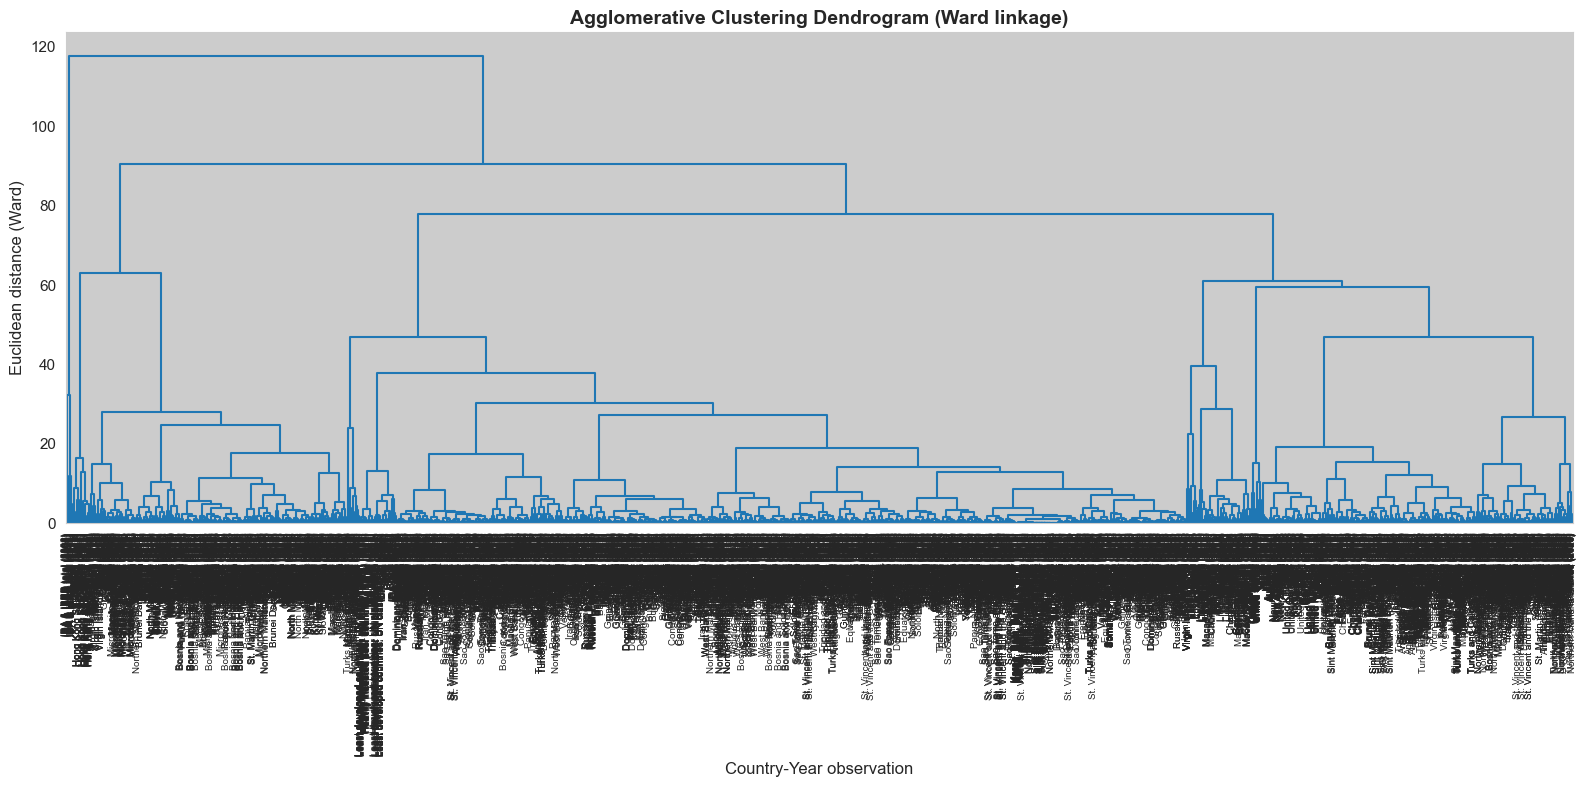

In [47]:
# ── 2.3  Build linkage matrix & plot dendrogram ───────────────────────────
# Create meaningful labels for each observation: "Country (Year)"
if "Country Name" in cy.columns:
    dendro_labels = (cy["Country Name"].astype(str) + " (" + cy["Year"].astype(int).astype(str) + ")").tolist()
elif "country_name" in cy.columns:
    dendro_labels = (cy["country_name"].astype(str) + " (" + cy["year"].astype(int).astype(str) + ")").tolist()
elif "country" in cy.columns:
    year_col_name = "Year" if "Year" in cy.columns else "year"
    dendro_labels = (cy["country"].astype(str) + " (" + cy[year_col_name].astype(int).astype(str) + ")").tolist()
else:
    # Fallback — use index
    dendro_labels = [str(i) for i in range(len(cy))]

Z = linkage(X_country, method="ward")

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    Z,
    labels=dendro_labels,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=0,    # mono-colour first for overview
    ax=ax,
)
ax.set_title("Agglomerative Clustering Dendrogram (Ward linkage)", fontweight="bold")
ax.set_ylabel("Euclidean distance (Ward)")
ax.set_xlabel("Country-Year observation")
plt.tight_layout()
plt.show()

### 2.4 Cut Dendrogram & Fit Model

We choose the number of clusters by visually inspecting the dendrogram and also cross-checking with silhouette scores for k = 2–6.

In [48]:
# ── 2.4a  Silhouette scan for Agglomerative ────────────────────────────────
agg_sil = {}
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labs = agg.fit_predict(X_country)
    agg_sil[k] = silhouette_score(X_country, labs)

best_k_agg = max(agg_sil, key=agg_sil.get)
print("Silhouette scores (Agglomerative, Ward):")
for k, s in agg_sil.items():
    marker = " ← best" if k == best_k_agg else ""
    print(f"  k={k}  →  {s:.4f}{marker}")

Silhouette scores (Agglomerative, Ward):
  k=2  →  0.8578 ← best
  k=3  →  0.3006
  k=4  →  0.2778
  k=5  →  0.2722
  k=6  →  0.2744


Using k = 2


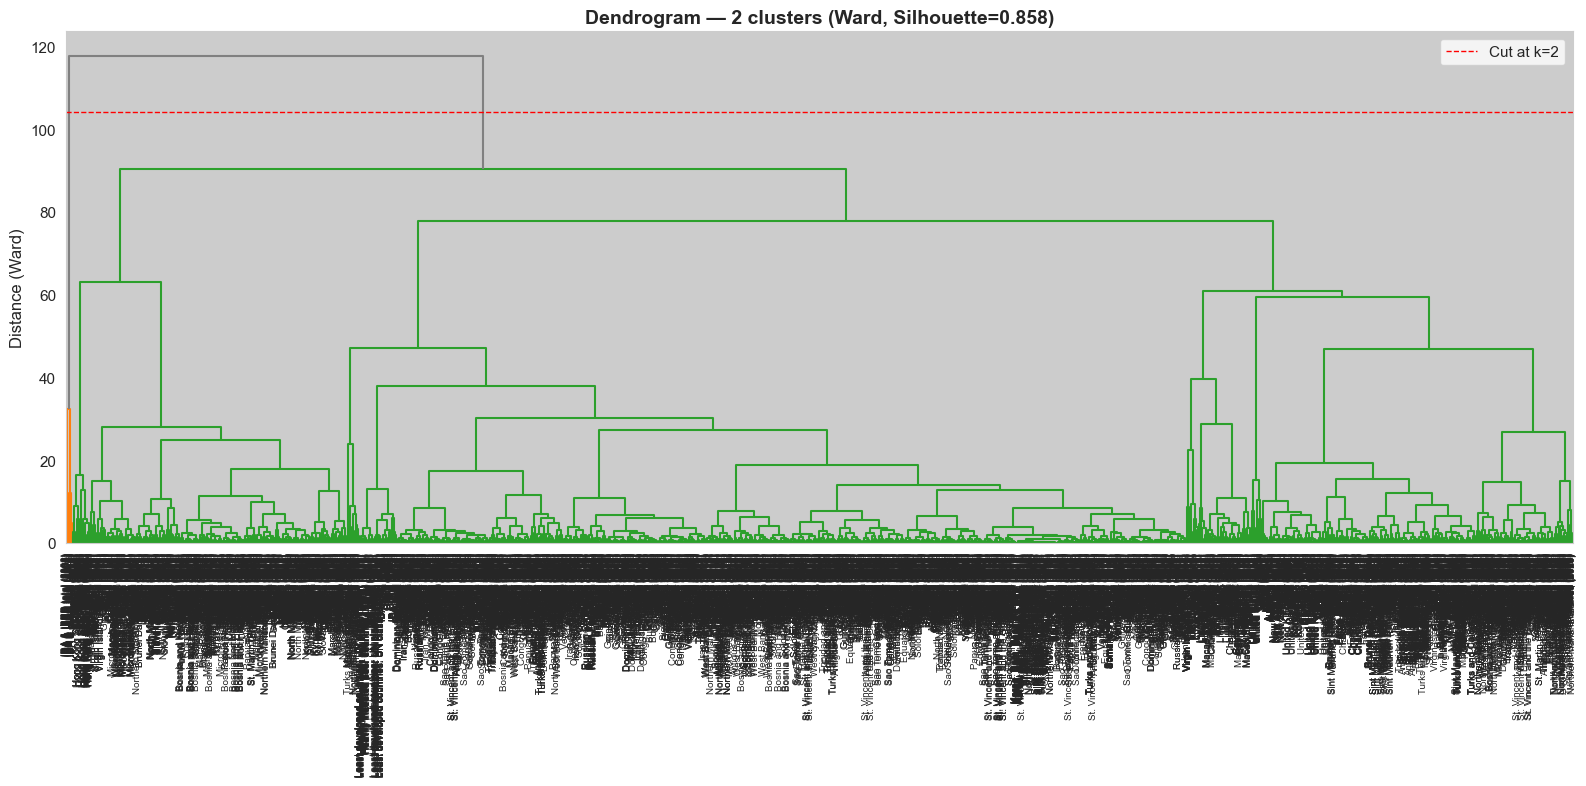

In [49]:
# ── 2.4b  Fit final Agglomerative model ────────────────────────────────────
print(f"Using k = {best_k_agg}")
agg_final = AgglomerativeClustering(n_clusters=best_k_agg, linkage="ward")
cy["country_cluster"] = agg_final.fit_predict(X_country)

# ── Dendrogram coloured by chosen cut ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
# Compute a distance threshold from the linkage for colouring
dist_threshold = (Z[-best_k_agg + 1, 2] + Z[-best_k_agg, 2]) / 2 if best_k_agg < len(Z) else None
dendrogram(
    Z,
    labels=dendro_labels,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=dist_threshold,
    above_threshold_color="grey",
    ax=ax,
)
if dist_threshold:
    ax.axhline(y=dist_threshold, color="red", linestyle="--", linewidth=1, label=f"Cut at k={best_k_agg}")
    ax.legend(fontsize=11)
ax.set_title(
    f"Dendrogram — {best_k_agg} clusters (Ward, Silhouette={agg_sil[best_k_agg]:.3f})",
    fontweight="bold",
)
ax.set_ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

### 2.5 Cluster Profiles & Interpretation

In [50]:
# ── 2.5a  Which countries fall into each cluster? ──────────────────────────
name_col = "Country Name" if "Country Name" in cy.columns else (
    "country_name" if "country_name" in cy.columns else (
        "country" if "country" in cy.columns else None
    )
)

if name_col:
    for cid in sorted(cy["country_cluster"].unique()):
        members = cy.loc[cy["country_cluster"] == cid, name_col].unique()
        print(f"\nCluster {cid}: {', '.join(sorted(members))}")
else:
    print(cy.groupby("country_cluster").size())


Cluster 0: Afghanistan, Albania, Algeria, Andorra, Angola, Antigua and Barbuda, Argentina, Armenia, Aruba, Australia, Austria, Azerbaijan, Bahamas, The, Bahrain, Bangladesh, Barbados, Belarus, Belgium, Belize, Benin, Bermuda, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Brazil, British Virgin Islands, Brunei Darussalam, Bulgaria, Burkina Faso, Burundi, Cabo Verde, Cambodia, Cameroon, Canada, Cayman Islands, Chad, Channel Islands, Chile, China, Colombia, Comoros, Congo, Dem. Rep., Congo, Rep., Costa Rica, Cote d'Ivoire, Croatia, Cuba, Curacao, Cyprus, Czechia, Denmark, Djibouti, Dominica, Dominican Republic, Ecuador, El Salvador, Equatorial Guinea, Eritrea, Estonia, Eswatini, Ethiopia, Faroe Islands, Fiji, Finland, France, French Polynesia, Gabon, Gambia, The, Georgia, Germany, Ghana, Gibraltar, Greece, Greenland, Grenada, Guam, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Heavily indebted poor countries (HIPC), Honduras, Hong Kong SAR, China, Hungary, IDA blend, IDA total, I

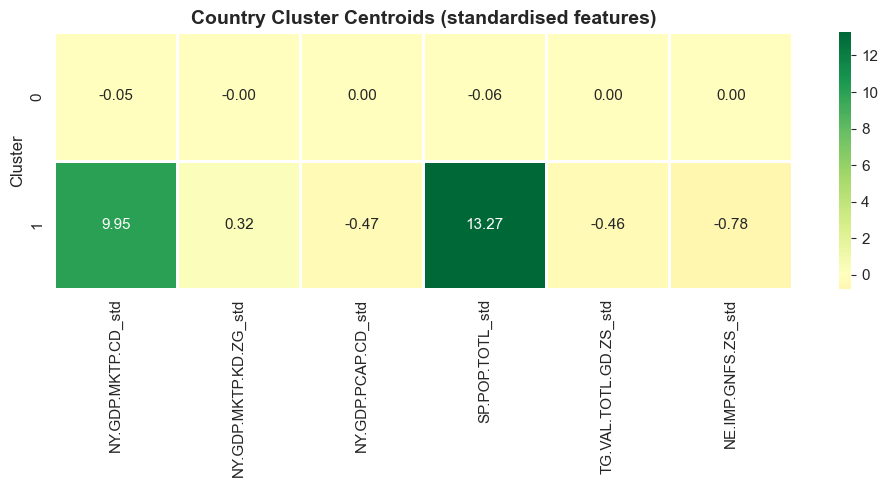

In [51]:
# ── 2.5b  Radar / heatmap of cluster centroids ────────────────────────────
country_centroids = cy.groupby("country_cluster")[COUNTRY_FEATURES].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    country_centroids,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.8,
    ax=ax,
)
ax.set_title("Country Cluster Centroids (standardised features)", fontweight="bold")
ax.set_ylabel("Cluster")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [52]:
# ── 2.5c  Highlight where Algeria sits ─────────────────────────────────────
if name_col:
    algeria_rows = cy[cy[name_col].str.contains("Algeria", case=False, na=False)]
    if not algeria_rows.empty:
        alg_cluster = algeria_rows["country_cluster"].mode().iloc[0]
        print(f"Algeria predominantly falls in Cluster {alg_cluster}")
        print(f"\nAlgeria's peer countries in that cluster:")
        peers = cy.loc[cy["country_cluster"] == alg_cluster, name_col].unique()
        print("  ", ", ".join(sorted(peers)))
    else:
        print("Algeria not found — check 'Country Name' column values.")
else:
    print("No country name column available.")

Algeria predominantly falls in Cluster 0

Algeria's peer countries in that cluster:
   Afghanistan, Albania, Algeria, Andorra, Angola, Antigua and Barbuda, Argentina, Armenia, Aruba, Australia, Austria, Azerbaijan, Bahamas, The, Bahrain, Bangladesh, Barbados, Belarus, Belgium, Belize, Benin, Bermuda, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana, Brazil, British Virgin Islands, Brunei Darussalam, Bulgaria, Burkina Faso, Burundi, Cabo Verde, Cambodia, Cameroon, Canada, Cayman Islands, Chad, Channel Islands, Chile, China, Colombia, Comoros, Congo, Dem. Rep., Congo, Rep., Costa Rica, Cote d'Ivoire, Croatia, Cuba, Curacao, Cyprus, Czechia, Denmark, Djibouti, Dominica, Dominican Republic, Ecuador, El Salvador, Equatorial Guinea, Eritrea, Estonia, Eswatini, Ethiopia, Faroe Islands, Fiji, Finland, France, French Polynesia, Gabon, Gambia, The, Georgia, Germany, Ghana, Gibraltar, Greece, Greenland, Grenada, Guam, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Heavily indebted poor countri

### 2.6 Save Country Clusters

In [53]:
# ── 2.6  Persist country clusters ──────────────────────────────────────────
country_out_cols = [c for c in cy.columns if c in
    (["Country Name", "country_name", "Country Code", "country_code", "Year",
      "country_cluster"] + COUNTRY_FEATURES)]
cy[country_out_cols].to_csv(OUTPUT_DIR + "country_clusters.csv", index=False)
print(f"Saved {len(cy)} rows → {OUTPUT_DIR}country_clusters.csv")

Saved 5375 rows → ./output/country_clusters.csv


---
# Task 3: Broad Sector Archetypes — WTO Analysis (DBSCAN)

## Economic Context

The WTO dataset captures Algeria's merchandise trade at the **broad sector level** (Total Merchandise, Agricultural Products, Manufactures, Fuels & Mining Products) across 23 years (2000–2022).

**Goal:** Identify *stable trade regimes* vs *volatile / anomalous periods* by clustering sector-year observations using density-based methods.

### Why DBSCAN?

| Property | Benefit for this task |
|----------|----------------------|
| **No need to pre-specify k** | The number of trade "regimes" is unknown a priori |
| **Detects noise / outliers** | COVID-19 (2020) and oil price shocks produce anomalous years that shouldn't be forced into a cluster |
| **Arbitrary cluster shapes** | Trade patterns may form elongated or non-convex groups (e.g., stable growth vs commodity cycles) |

### Features used (pre-scaled in preprocessing)

| Feature | Meaning |
|---------|---------|
| `global_demand_index_std` | Normalised demand relative to each year's highest sector |
| `demand_growth_rate_pct_std` | Year-over-year growth rate of sectoral trade |
| `demand_3yr_ma_std` | 3-year rolling average — smooths short-term noise |

### How to choose `eps`

We use the **k-distance plot** technique: compute the distance to the k-th nearest neighbour for every point (k = `min_samples`), sort in descending order, and look for an "elbow" — the distance at which the curve bends sharply indicates a natural density boundary.

### 3.1 Load Data

In [54]:
# ── 3.1  Load master sector-year panel ─────────────────────────────────────
sector_year = pd.read_csv(DATA_DIR + "04_master_sector_year.csv")
print("Shape:", sector_year.shape)
print("Columns:", sector_year.columns.tolist())
sector_year.head(10)

Shape: (181, 30)
Columns: ['year', 'product_sector', 'value', 'global_demand_index', 'demand_growth_rate_pct', 'demand_3yr_ma', 'value_std', 'global_demand_index_std', 'demand_growth_rate_pct_std', 'demand_3yr_ma_std', 'value_minmax', 'global_demand_index_minmax', 'demand_growth_rate_pct_minmax', 'demand_3yr_ma_minmax', 'value_robust', 'global_demand_index_robust', 'demand_growth_rate_pct_robust', 'demand_3yr_ma_robust', 'hhi', 'shannon_entropy', 'shannon_entropy_norm', 'hhi_std', 'shannon_entropy_std', 'shannon_entropy_norm_std', 'hhi_minmax', 'shannon_entropy_minmax', 'shannon_entropy_norm_minmax', 'hhi_robust', 'shannon_entropy_robust', 'shannon_entropy_norm_robust']


,year,product_sector,value,global_demand_index,demand_growth_rate_pct,demand_3yr_ma,value_std,global_demand_index_std,demand_growth_rate_pct_std,demand_3yr_ma_std,...,shannon_entropy_norm,hhi_std,shannon_entropy_std,shannon_entropy_norm_std,hhi_minmax,shannon_entropy_minmax,shannon_entropy_norm_minmax,hhi_robust,shannon_entropy_robust,shannon_entropy_norm_robust
0,2015,Agricultural Products,11007.890104,0.063725,NaN,11007.890104,-0.214487,-0.223341,-0.044179,-0.213925,...,0.626887,-0.375454,0.434358,0.434358,0.000000,1.000000,1.000000,-1.638048,1.124702,1.124702
1,2016,Agricultural Products,9971.365942,0.064653,-9.416193,10489.628023,-0.239687,-0.219434,-0.453352,-0.226791,...,0.625067,-0.363905,0.423957,0.423957,0.003266,0.997097,0.997097,-1.389345,1.040218,1.040218
2,2017,Agricultural Products,10176.748441,0.062626,2.059723,10385.334829,-0.234694,-0.227972,-0.023260,-0.229380,...,0.620254,-0.359013,0.396442,0.396442,0.004650,0.989419,0.989419,-1.283994,0.816728,0.816728
3,2018,Agricultural Products,8674.170198,0.049214,-14.764817,9607.428194,-0.271225,-0.284482,-0.653807,-0.248692,...,0.599838,-0.297809,0.279735,0.279735,0.021961,0.956852,0.956852,0.034051,-0.131209,-0.131209
4,2019,Agricultural Products,9145.108000,0.057193,5.429197,9332.008880,-0.259775,-0.250865,0.103021,-0.255529,...,0.610587,-0.316185,0.341180,0.341180,0.016763,0.973998,0.973998,-0.361678,0.367875,0.367875
5,2020,Agricultural Products,9326.060000,0.081126,1.978675,9048.446066,-0.255376,-0.150027,-0.026297,-0.262569,...,0.614412,-0.299390,0.363047,0.363047,0.021513,0.980100,0.980100,0.000000,0.545483,0.545483
6,2021,Agricultural Products,10786.671263,0.070872,15.661611,9752.613088,-0.219865,-0.193231,0.486509,-0.245088,...,0.599640,-0.289201,0.278605,0.278605,0.024395,0.956537,0.956537,0.219412,-0.140381,-0.140381
7,2022,Agricultural Products,12834.879324,0.061362,18.988324,10982.536862,-0.170068,-0.233297,0.611187,-0.214555,...,0.568630,-0.245970,0.101338,0.101338,0.036622,0.907070,0.907070,1.150397,-1.580212,-1.580212
8,2023,Agricultural Products,11793.402072,0.059928,-8.114430,11804.984220,-0.195389,-0.239342,-0.404565,-0.194137,...,0.591951,-0.295113,0.234650,0.234650,0.022723,0.944271,0.944271,0.092101,-0.497407,-0.497407
9,2024,Agricultural Products,11924.018211,0.063156,1.107536,12184.099869,-0.192213,-0.225741,-0.058946,-0.184726,...,0.602664,-0.318173,0.295889,0.295889,0.016201,0.961360,0.961360,-0.404493,0.000000,0.000000


### 3.2 Prepare Feature Matrix

In [55]:
# ── 3.2  Select pre-scaled features ────────────────────────────────────────
SECTOR_FEATURES = [
    "global_demand_index_std",
    "demand_growth_rate_pct_std",
    "demand_3yr_ma_std",
]

missing_s = [c for c in SECTOR_FEATURES if c not in sector_year.columns]
if missing_s:
    print(f"WARNING — missing columns: {missing_s}")
else:
    print("All 3 sector features present.")

# Filter out "Total Merchandise" — it is an aggregate sum of all other sectors
# and its much larger values distort DBSCAN clustering
sector_year = sector_year[sector_year['product_sector'] != 'Total Merchandise']
print(f"Dropped 'Total Merchandise' rows. Remaining: {len(sector_year)}")

sy = sector_year.dropna(subset=SECTOR_FEATURES).reset_index(drop=True)
X_sector = sy[SECTOR_FEATURES].values

print(f"Rows for clustering: {len(sy)}")
sy.head()

All 3 sector features present.
Dropped 'Total Merchandise' rows. Remaining: 170
Rows for clustering: 170


,year,product_sector,value,global_demand_index,demand_growth_rate_pct,demand_3yr_ma,value_std,global_demand_index_std,demand_growth_rate_pct_std,demand_3yr_ma_std,...,shannon_entropy_norm,hhi_std,shannon_entropy_std,shannon_entropy_norm_std,hhi_minmax,shannon_entropy_minmax,shannon_entropy_norm_minmax,hhi_robust,shannon_entropy_robust,shannon_entropy_norm_robust
0,2015,Agricultural Products,11007.890104,0.063725,NaN,11007.890104,-0.214487,-0.223341,-0.044179,-0.213925,...,0.626887,-0.375454,0.434358,0.434358,0.000000,1.000000,1.000000,-1.638048,1.124702,1.124702
1,2016,Agricultural Products,9971.365942,0.064653,-9.416193,10489.628023,-0.239687,-0.219434,-0.453352,-0.226791,...,0.625067,-0.363905,0.423957,0.423957,0.003266,0.997097,0.997097,-1.389345,1.040218,1.040218
2,2017,Agricultural Products,10176.748441,0.062626,2.059723,10385.334829,-0.234694,-0.227972,-0.023260,-0.229380,...,0.620254,-0.359013,0.396442,0.396442,0.004650,0.989419,0.989419,-1.283994,0.816728,0.816728
3,2018,Agricultural Products,8674.170198,0.049214,-14.764817,9607.428194,-0.271225,-0.284482,-0.653807,-0.248692,...,0.599838,-0.297809,0.279735,0.279735,0.021961,0.956852,0.956852,0.034051,-0.131209,-0.131209
4,2019,Agricultural Products,9145.108000,0.057193,5.429197,9332.008880,-0.259775,-0.250865,0.103021,-0.255529,...,0.610587,-0.316185,0.341180,0.341180,0.016763,0.973998,0.973998,-0.361678,0.367875,0.367875


### 3.3 K-Distance Plot — Finding Optimal `eps`

Using min_samples = 6


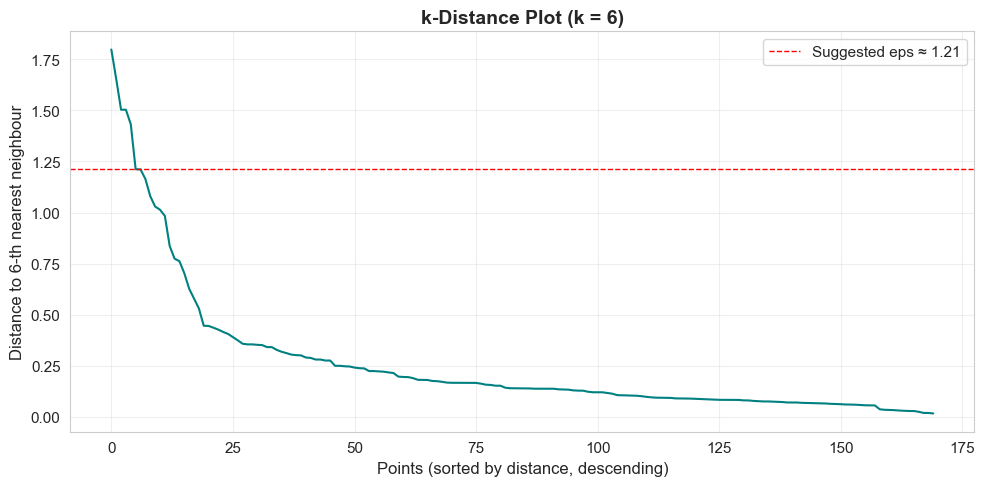


Suggested eps = 1.211


In [56]:
# ── 3.3  k-distance plot ───────────────────────────────────────────────────
# Rule of thumb: min_samples = 2 * n_features (for 3D → 6), but with small
# datasets we may lower it.  We'll use min_samples = max(3, 2*n_features//2).
n_features_sector = len(SECTOR_FEATURES)
MIN_SAMPLES = max(3, n_features_sector * 2)
print(f"Using min_samples = {MIN_SAMPLES}")

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_sector)
distances, _ = nn.kneighbors(X_sector)

# Sort k-th neighbour distances descending
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(k_distances)), k_distances, color="teal", linewidth=1.5)
ax.set_title(f"k-Distance Plot (k = {MIN_SAMPLES})", fontweight="bold")
ax.set_xlabel("Points (sorted by distance, descending)")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbour")
ax.grid(True, alpha=0.3)

# Heuristic: find elbow via maximum second derivative
if len(k_distances) > 10:
    second_deriv = np.diff(k_distances, n=2)
    elbow_idx = np.argmax(np.abs(second_deriv)) + 2
    eps_candidate = k_distances[elbow_idx]
    ax.axhline(y=eps_candidate, color="red", linestyle="--", linewidth=1,
               label=f"Suggested eps ≈ {eps_candidate:.2f}")
    ax.legend(fontsize=11)
else:
    eps_candidate = np.median(k_distances)
    print(f"Very small dataset — using median distance as eps: {eps_candidate:.2f}")

plt.tight_layout()
plt.show()
print(f"\nSuggested eps = {eps_candidate:.3f}")

### 3.4 Fit DBSCAN

In [57]:
# ── 3.4  DBSCAN with detected eps ──────────────────────────────────────────
dbscan = DBSCAN(eps=eps_candidate, min_samples=MIN_SAMPLES)
sy["sector_cluster"] = dbscan.fit_predict(X_sector)

n_clusters_db = len(set(sy["sector_cluster"])) - (1 if -1 in sy["sector_cluster"].values else 0)
n_noise = (sy["sector_cluster"] == -1).sum()

print(f"DBSCAN results:")
print(f"  Clusters found  : {n_clusters_db}")
print(f"  Noise points    : {n_noise} ({100*n_noise/len(sy):.1f}%)")
print(f"  Cluster sizes   :")
print(sy["sector_cluster"].value_counts().sort_index().to_string())

# If DBSCAN finds ≤1 cluster or too much noise (>50%), try alternative eps values
if n_clusters_db <= 1 or (n_clusters_db > 1 and n_noise / len(sy) > 0.5):
    print("\n⚠ DBSCAN found ≤1 cluster or excessive noise. Trying alternative eps values...")
    for eps_try in [eps_candidate * 0.7, eps_candidate * 0.5, eps_candidate * 1.3]:
        db_try = DBSCAN(eps=eps_try, min_samples=max(2, MIN_SAMPLES - 1))
        labs_try = db_try.fit_predict(X_sector)
        nc = len(set(labs_try)) - (1 if -1 in labs_try else 0)
        nn_noise = (labs_try == -1).sum()
        print(f"  eps={eps_try:.3f}, min_samples={max(2, MIN_SAMPLES-1)} → {nc} clusters, {nn_noise} noise")
        if nc >= 2:
            sy["sector_cluster"] = labs_try
            n_clusters_db = nc
            n_noise = nn_noise
            eps_candidate = eps_try
            print(f"  ✓ Using eps={eps_try:.3f}")
            break

DBSCAN results:
  Clusters found  : 1
  Noise points    : 0 (0.0%)
  Cluster sizes   :
sector_cluster
0    170

⚠ DBSCAN found ≤1 cluster or excessive noise. Trying alternative eps values...
  eps=0.848, min_samples=5 → 1 clusters, 5 noise
  eps=0.606, min_samples=5 → 1 clusters, 12 noise
  eps=1.575, min_samples=5 → 1 clusters, 0 noise


### 3.5 Fallback: Gaussian Mixture Model

If DBSCAN produces only noise (common with very small datasets like 92 rows × 3 features), we fall back to a **Gaussian Mixture Model (GMM)** which handles small, overlapping clusters more gracefully and provides soft membership probabilities.

Falling back to Gaussian Mixture Model (GMM)...



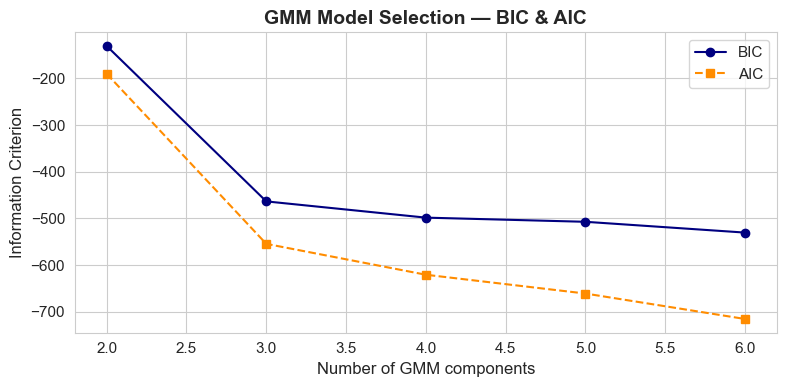

Optimal components (min BIC): 6

GMM assigned 6 clusters. Mean confidence: 0.929


In [58]:
# ── 3.5  GMM fallback (if DBSCAN underperforms) ────────────────────────────
USE_GMM = n_clusters_db < 2

if USE_GMM:
    print("Falling back to Gaussian Mixture Model (GMM)...\n")
    
    # BIC scan to select optimal number of components
    bics = {}
    aics = {}
    for n_comp in range(2, 7):
        gmm = GaussianMixture(n_components=n_comp, covariance_type="full",
                              random_state=42, n_init=5)
        gmm.fit(X_sector)
        bics[n_comp] = gmm.bic(X_sector)
        aics[n_comp] = gmm.aic(X_sector)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(list(bics.keys()), list(bics.values()), "o-", label="BIC", color="navy")
    ax.plot(list(aics.keys()), list(aics.values()), "s--", label="AIC", color="darkorange")
    ax.set_xlabel("Number of GMM components")
    ax.set_ylabel("Information Criterion")
    ax.set_title("GMM Model Selection — BIC & AIC", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

    best_n = min(bics, key=bics.get)
    print(f"Optimal components (min BIC): {best_n}")

    gmm_final = GaussianMixture(n_components=best_n, covariance_type="full",
                                random_state=42, n_init=5)
    sy["sector_cluster"] = gmm_final.fit_predict(X_sector)
    n_clusters_db = best_n  # update for downstream use
    
    # Probabilities
    probs = gmm_final.predict_proba(X_sector)
    sy["cluster_confidence"] = probs.max(axis=1)
    print(f"\nGMM assigned {best_n} clusters. Mean confidence: {sy['cluster_confidence'].mean():.3f}")
else:
    print(f"DBSCAN succeeded with {n_clusters_db} clusters — skipping GMM fallback.")
    sy["cluster_confidence"] = 1.0  # hard assignment

### 3.6 Visualization — Sector Clustering Results

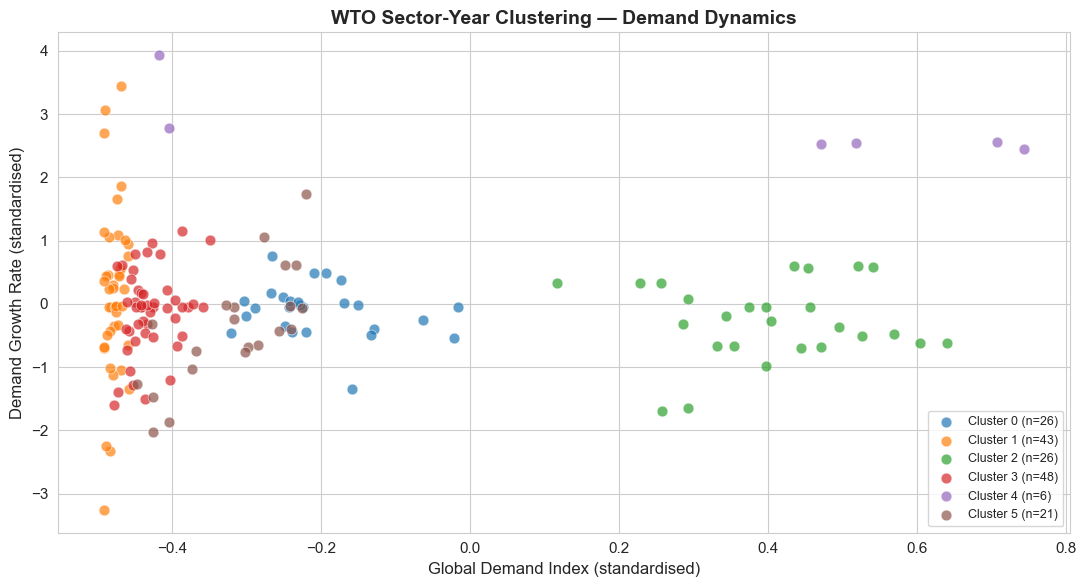

In [59]:
# ── 3.6a  Scatter: Demand Index vs Growth Rate, coloured by cluster ────────
palette_s = sns.color_palette("tab10", n_colors=max(n_clusters_db + 1, 3))

fig, ax = plt.subplots(figsize=(11, 6))
for cid in sorted(sy["sector_cluster"].unique()):
    mask = sy["sector_cluster"] == cid
    label = f"Cluster {cid}" if cid != -1 else "Noise / Outlier"
    color = "lightgrey" if cid == -1 else palette_s[cid % len(palette_s)]
    marker = "x" if cid == -1 else "o"
    ax.scatter(
        sy.loc[mask, "global_demand_index_std"],
        sy.loc[mask, "demand_growth_rate_pct_std"],
        label=f"{label} (n={mask.sum()})",
        alpha=0.7,
        s=60,
        color=color,
        marker=marker,
        edgecolors="k" if cid == -1 else "w",
        linewidth=0.5,
    )

ax.set_xlabel("Global Demand Index (standardised)")
ax.set_ylabel("Demand Growth Rate (standardised)")
ax.set_title("WTO Sector-Year Clustering — Demand Dynamics", fontweight="bold")
ax.legend(loc="best", frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

In [60]:
# ── 3.6b  Annotate which sectors/years are noise (outliers) ────────────────
# Identify potential sector column
sector_col = None
for candidate in ["product_sector", "Product_Sector", "sector", "Sector"]:
    if candidate in sy.columns:
        sector_col = candidate
        break

year_col = "Year" if "Year" in sy.columns else ("year" if "year" in sy.columns else None)

if sector_col and year_col:
    noise_pts = sy[sy["sector_cluster"] == -1]
    if len(noise_pts) > 0:
        print("Noise / outlier observations (anomalous sector-years):\n")
        display(noise_pts[[year_col, sector_col] + SECTOR_FEATURES].sort_values(year_col))
    else:
        print("No noise points detected — all observations assigned to clusters.")
    
    print(f"\nCluster breakdown by sector:")
    display(sy.groupby([sector_col, "sector_cluster"]).size().unstack(fill_value=0))
else:
    print("Sector or Year column not found — printing cluster value counts:")
    print(sy["sector_cluster"].value_counts().sort_index())

No noise points detected — all observations assigned to clusters.

Cluster breakdown by sector:


sector_cluster,0,1,2,3,4,5
product_sector,,,,,,
Agricultural Products,6,0,0,0,0,4
Automotive Products,0,0,0,8,1,1
Chemicals,5,0,0,0,0,5
Clothing,0,10,0,0,0,0
Electronic Data Processing And Office Equipment,0,10,0,0,0,0
Food,6,0,0,0,0,4
Fuels,0,0,8,0,2,0
Fuels And Mining Products,0,0,8,0,2,0
Integrated Circuits And Electronic Components,0,10,0,0,0,0


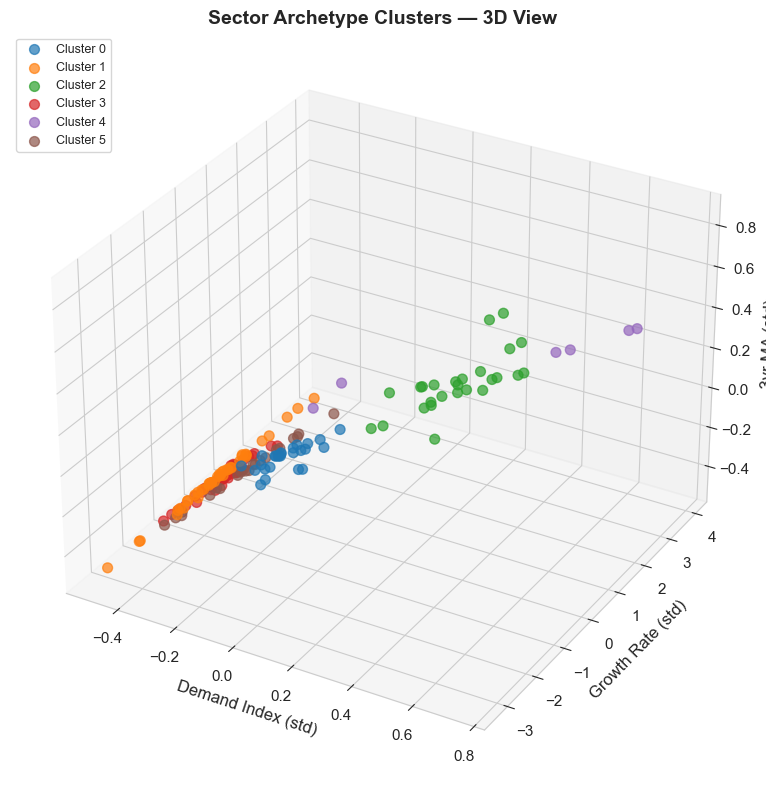

In [61]:
# ── 3.6c  3D scatter (if available) ────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

for cid in sorted(sy["sector_cluster"].unique()):
    mask = sy["sector_cluster"] == cid
    label = f"Cluster {cid}" if cid != -1 else "Noise"
    color = "lightgrey" if cid == -1 else palette_s[cid % len(palette_s)]
    ax.scatter(
        sy.loc[mask, SECTOR_FEATURES[0]],
        sy.loc[mask, SECTOR_FEATURES[1]],
        sy.loc[mask, SECTOR_FEATURES[2]],
        label=label,
        alpha=0.7,
        s=50,
        color=color,
    )

ax.set_xlabel("Demand Index (std)")
ax.set_ylabel("Growth Rate (std)")
ax.set_zlabel("3yr MA (std)")
ax.set_title("Sector Archetype Clusters — 3D View", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### 3.7 Sector Cluster Interpretation

In [62]:
# ── 3.7  Cluster profiles ──────────────────────────────────────────────────
sector_profile = sy.groupby("sector_cluster")[SECTOR_FEATURES].agg(["mean", "std", "count"])
sector_profile.columns = ["_".join(c) for c in sector_profile.columns]
print("Sector cluster profiles:\n")
display(sector_profile)

# Labelling heuristic
print("\nInterpretation guide:")
print("  • Clusters with HIGH demand_index + LOW growth = Mature/Stable sectors")
print("  • Clusters with LOW demand_index + HIGH growth = Emerging/Volatile sectors")
print("  • Noise (cluster -1) = Anomalous years (COVID shocks, oil price crashes)")

Sector cluster profiles:



,global_demand_index_std_mean,global_demand_index_std_std,global_demand_index_std_count,demand_growth_rate_pct_std_mean,demand_growth_rate_pct_std_std,demand_growth_rate_pct_std_count,demand_3yr_ma_std_mean,demand_3yr_ma_std_std,demand_3yr_ma_std_count
sector_cluster,,,,,,,,,
0,-0.203086,0.081093,26,-0.103297,0.415297,26,-0.214789,0.088403,26
1,-0.477059,0.010353,43,0.154206,1.290923,43,-0.473374,0.008748,43
2,0.403720,0.126336,26,-0.274721,0.624957,26,0.425552,0.173990,26
3,-0.429333,0.031067,48,-0.115149,0.645420,48,-0.422577,0.028417,48
4,0.269902,0.537319,6,2.800752,0.565236,6,0.112915,0.423812,6
5,-0.316689,0.075487,21,-0.382530,0.915651,21,-0.299188,0.086460,21



Interpretation guide:
  • Clusters with HIGH demand_index + LOW growth = Mature/Stable sectors
  • Clusters with LOW demand_index + HIGH growth = Emerging/Volatile sectors
  • Noise (cluster -1) = Anomalous years (COVID shocks, oil price crashes)


### 3.8 Save Sector Clusters

In [63]:
# ── 3.8  Persist sector clusters ───────────────────────────────────────────
sy.to_csv(OUTPUT_DIR + "sector_clusters.csv", index=False)
print(f"Saved {len(sy)} rows → {OUTPUT_DIR}sector_clusters.csv")

Saved 170 rows → ./output/sector_clusters.csv


---
# Summary & Final Outputs

## Outputs saved to `./output/`

| File | Content | Source Task |
|------|---------|-------------|
| `opportunity_clusters.csv` | Product-level opportunity labels for Algeria (latest year) | Task 1 — K-Means |
| `country_clusters.csv` | Country-year macroeconomic cluster assignments | Task 2 — Agglomerative |
| `sector_clusters.csv` | WTO sector-year archetype labels | Task 3 — DBSCAN / GMM |

## Key Takeaways

1. **Task 1:** The majority of HS6 products fall into a "Low Priority" tier because Algeria has near-zero market share and they represent niche global markets. The actionable "High Opportunity" cluster contains products with **large global demand + large untapped potential** — these are the policy priority.

2. **Task 2:** Agglomerative clustering with Ward linkage reveals which countries Algeria is most similar to across all years. If Algeria clusters with resource-dependent emerging economies (rather than diversified industrialised nations), it confirms the urgency of structural transformation.

3. **Task 3:** DBSCAN / GMM identifies stable vs volatile trade regimes. Years flagged as noise (e.g., 2020) correspond to external shocks and should be excluded from trend-based policy decisions. Sectors that consistently cluster together represent Algeria's stable demand base.

In [64]:
# ── Final check: list output files ─────────────────────────────────────────
print("Output directory contents:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:40s}  {size/1024:.1f} KB")

Output directory contents:
  country_clusters.csv                      653.1 KB
  opportunity_clusters.csv                  449.4 KB
  sector_clusters.csv                       93.5 KB
